# Job Market Skills Analysis Using Web Scraping and NLP

This project focuses on analyzing real-world job market trends by collecting live job posting data from the web using both API-based extraction and web scraping techniques. The collected data, including job descriptions and metadata, is cleaned and processed using Natural Language Processing (NLP) methods to extract key skills, classify job roles, and identify patterns in hiring demand. The analysis provides insights into in-demand skills, salary trends, and role distribution, helping understand the current job market landscape for data-related roles.

In [1]:
# 1) INSTALL REQUIREMENTS

!pip -q install pandas numpy requests beautifulsoup4 lxml matplotlib scikit-learn tqdm wordcloud nltk

In [2]:
# 2) IMPORTS

import os
import re
import time
import html
import random
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from bs4 import BeautifulSoup
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud, STOPWORDS
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
# 3) CONFIG

API_URL = "https://remoteok.com/api"
BASE_URL = "https://remoteok.com"
OUTPUT_DIR = "/content/job_market_project_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9"
}

MAX_PAGES_TO_SCRAPE = 40
REQUEST_SLEEP_SEC = 1.2
RANDOM_SEED = 42

In [4]:
# 4) ANALYTICS SCOPE

ANALYTICS_ROLE_KEYWORDS = [
    "data analyst", "business analyst", "analytics engineer", "bi analyst",
    "business intelligence", "data scientist", "data engineer",
    "machine learning", "ml engineer", "machine learning engineer",
    "product analyst", "marketing analyst", "insights analyst",
    "reporting analyst", "research analyst", "risk analyst",
    "fraud analyst", "operations analyst", "decision scientist",
    "sql", "python", "tableau", "power bi", "analytics"
]

SKILL_PATTERNS = {
    "python": [r"\bpython\b"],
    "sql": [r"\bsql\b", r"\bpostgresql\b", r"\bpostgres\b", r"\bmysql\b", r"\bsql server\b", r"\bsnowflake\b"],
    "excel": [r"\bexcel\b", r"\bgoogle sheets\b", r"\bspreadsheets?\b"],
    "tableau": [r"\btableau\b"],
    "power bi": [r"\bpower\s?bi\b"],
    "looker": [r"\blooker\b", r"\blookml\b"],
    "google analytics": [r"\bgoogle analytics\b", r"\bga4\b"],
    "r": [r"(?<![a-zA-Z])r(?![a-zA-Z])", r"\br language\b"],
    "pandas": [r"\bpandas\b"],
    "numpy": [r"\bnumpy\b"],
    "scikit-learn": [r"\bscikit[\s-]?learn\b", r"\bsklearn\b"],
    "tensorflow": [r"\btensorflow\b"],
    "pytorch": [r"\bpytorch\b"],
    "spark": [r"\bspark\b", r"\bpyspark\b"],
    "hadoop": [r"\bhadoop\b"],
    "airflow": [r"\bairflow\b"],
    "dbt": [r"\bdbt\b"],
    "etl": [r"\betl\b", r"\belt\b"],
    "aws": [r"\baws\b", r"\bamazon web services\b"],
    "azure": [r"\bazure\b"],
    "gcp": [r"\bgcp\b", r"\bgoogle cloud\b"],
    "bigquery": [r"\bbigquery\b"],
    "redshift": [r"\bredshift\b"],
    "databricks": [r"\bdatabricks\b"],
    "git": [r"\bgit\b", r"\bgithub\b"],
    "docker": [r"\bdocker\b"],
    "kubernetes": [r"\bkubernetes\b", r"\bk8s\b"],
    "statistics": [r"\bstatistics\b", r"\bstatistical\b"],
    "a/b testing": [r"\ba\/b testing\b", r"\bab testing\b", r"\bexperimentation\b"],
    "machine learning": [r"\bmachine learning\b", r"\bml models?\b", r"\bml engineering\b"],
    "deep learning": [r"\bdeep learning\b"],
    "nlp": [r"\bnlp\b", r"\bnatural language processing\b"],
    "data visualization": [r"\bdashboards?\b", r"\breporting\b", r"\bvisualization\b"]
}

ROLE_FAMILY_PATTERNS = {
    "Data Analyst": [
        r"\bdata analyst\b",
        r"\bproduct analyst\b",
        r"\bmarketing analyst\b",
        r"\binsights analyst\b",
        r"\breporting analyst\b",
        r"\bbi analyst\b",
        r"\bbusiness intelligence analyst\b",
        r"\banalytics analyst\b",
        r"\bdecision analyst\b",
        r"\bdata analytics\b",
        r"\bmetrics\b",
        r"\bdashboard\b"
    ],
    "Business Analyst": [
        r"\bbusiness analyst\b",
        r"\boperations analyst\b",
        r"\brisk analyst\b",
        r"\bfraud analyst\b",
        r"\bresearch analyst\b",
        r"\bstrategy analyst\b"
    ],
    "Data Scientist": [
        r"\bdata scientist\b",
        r"\bapplied scientist\b",
        r"\bdecision scientist\b",
        r"\bresearch scientist\b"
    ],
    "Data Engineer": [
        r"\bdata engineer\b",
        r"\banalytics engineer\b",
        r"\bdata platform\b",
        r"\bdata warehouse\b",
        r"\betl engineer\b",
        r"\bpipeline engineer\b",
        r"\bdata pipelines?\b"
    ],
    "ML Engineer": [
        r"\bml engineer\b",
        r"\bmachine learning engineer\b",
        r"\bai engineer\b",
        r"\bpersonalization engineer\b",
        r"\bmlops\b",
        r"\bartificial intelligence\b"
    ]
}

SENIORITY_PATTERNS = {
    "Intern": [r"\bintern\b"],
    "Junior": [r"\bjunior\b", r"\bentry[- ]level\b", r"\bassociate\b"],
    "Mid": [r"\bmid\b", r"\bintermediate\b"],
    "Senior": [r"\bsenior\b", r"\bsr\.?\b", r"\blead\b", r"\bprincipal\b", r"\bstaff\b"],
    "Manager+": [r"\bmanager\b", r"\bdirector\b", r"\bhead\b", r"\bvp\b", r"\bvice president\b"]
}

compiled_skill_patterns = {
    skill: [re.compile(p, re.IGNORECASE) for p in patterns]
    for skill, patterns in SKILL_PATTERNS.items()
}

In [5]:
# 5) HELPER FUNCTIONS

def save_plot(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved plot: {path}")

def fix_encoding_artifacts(text):
    text = str(text)
    replacements = {
        "â€™": "'",
        "â€œ": '"',
        "â€": '"',
        "â€“": "-",
        "â€”": "-",
        "â€": '"',
        "Â": " ",
        "â": " ",
        "youâ": "you",
        "\xa0": " "
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    return text

def fetch_remoteok_jobs():
    response = requests.get(API_URL, headers=HEADERS, timeout=30)
    response.raise_for_status()
    data = response.json()
    jobs = [item for item in data if isinstance(item, dict) and "id" in item]
    if not jobs:
        raise ValueError("No job records found in API response.")
    return pd.DataFrame(jobs)

def html_to_text(raw_html):
    if pd.isna(raw_html):
        return ""
    raw_html = html.unescape(str(raw_html))
    raw_html = fix_encoding_artifacts(raw_html)
    soup = BeautifulSoup(raw_html, "lxml")
    for tag in soup(["script", "style", "noscript", "svg"]):
        tag.decompose()
    text = soup.get_text(separator=" ")
    text = fix_encoding_artifacts(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_text(text):
    text = fix_encoding_artifacts(text)
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\+\#\/\.\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_analytics_role(text):
    text = str(text).lower()
    return any(keyword in text for keyword in ANALYTICS_ROLE_KEYWORDS)

def extract_skills(text):
    text = str(text)
    found = set()
    for skill, patterns in compiled_skill_patterns.items():
        for pattern in patterns:
            if pattern.search(text):
                found.add(skill)
                break
    return sorted(found)

def classify_role_family(text):
    text = str(text).lower()
    for family, patterns in ROLE_FAMILY_PATTERNS.items():
        for pattern in patterns:
            if re.search(pattern, text):
                return family
    return "Other"

def classify_seniority(title):
    title = str(title).lower()
    for level, patterns in SENIORITY_PATTERNS.items():
        for pattern in patterns:
            if re.search(pattern, title):
                return level
    return "Unspecified"

def compute_salary_avg(row):
    mn = pd.to_numeric(row.get("salary_min", np.nan), errors="coerce")
    mx = pd.to_numeric(row.get("salary_max", np.nan), errors="coerce")
    if pd.notna(mn) and mn > 0 and pd.notna(mx) and mx > 0:
        return (mn + mx) / 2
    if pd.notna(mx) and mx > 0:
        return mx
    if pd.notna(mn) and mn > 0:
        return mn
    return np.nan

def normalize_job_url(url):
    if pd.isna(url):
        return np.nan
    url = str(url).strip()
    if not url:
        return np.nan
    if url.startswith("http://") or url.startswith("https://"):
        return url
    if url.startswith("/"):
        return BASE_URL + url
    return BASE_URL + "/" + url

def clean_scraped_page_text(text):
    text = fix_encoding_artifacts(text)
    text = str(text).lower()
    junk_patterns = [
        r"apply now", r"share this job", r"sign in", r"privacy policy",
        r"terms of service", r"cookie policy", r"browse jobs", r"posted by",
        r"apply for this job", r"subscribe", r"log in", r"remote ok",
        r"post a job", r"show more", r"hide this", r"cookie", r"privacy"
    ]
    for pat in junk_patterns:
        text = re.sub(pat, " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def scrape_job_page_text(url):
    try:
        response = requests.get(url, headers=HEADERS, timeout=30)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "lxml")

        for tag in soup(["script", "style", "noscript", "svg"]):
            tag.decompose()

        candidate_texts = []
        selectors = ["article", "main", "div.description", "div.job", "section", "body"]

        for selector in selectors:
            nodes = soup.select(selector)
            for node in nodes:
                txt = node.get_text(" ", strip=True)
                if len(txt) > 500:
                    candidate_texts.append(txt)

        text = max(candidate_texts, key=len) if candidate_texts else soup.get_text(" ", strip=True)
        text = fix_encoding_artifacts(text)
        text = re.sub(r"\s+", " ", text).strip()
        text = clean_scraped_page_text(text)
        return text
    except Exception:
        return ""

def scrape_selected_job_pages(df_input, max_pages=40, sleep_sec=1.2, seed=42):
    df_copy = df_input.copy()
    df_copy["job_url"] = df_copy["url"].apply(normalize_job_url)

    unique_urls = df_copy["job_url"].dropna().drop_duplicates().tolist()
    if len(unique_urls) == 0:
        df_copy["scraped_page_text"] = ""
        return df_copy

    random.seed(seed)
    sample_size = min(max_pages, len(unique_urls))
    sampled_urls = random.sample(unique_urls, sample_size)

    scraped_map = {}
    for url in tqdm(sampled_urls, desc="Scraping job pages"):
        scraped_map[url] = scrape_job_page_text(url)
        time.sleep(sleep_sec)

    df_copy["scraped_page_text"] = df_copy["job_url"].map(scraped_map).fillna("")
    return df_copy

def merge_texts(api_text, scraped_text):
    api_text = str(api_text or "")
    scraped_text = str(scraped_text or "")

    if len(scraped_text) == 0:
        return api_text

    if len(scraped_text) > len(api_text) * 1.2:
        return api_text + " " + scraped_text

    return api_text

def is_useful_scrape(text):
    text = str(text).lower()
    bad_terms = [
        "privacy policy", "sign in", "cookie", "subscribe",
        "post a job", "terms of service", "browse jobs"
    ]
    bad_count = sum(term in text for term in bad_terms)
    unique_words = len(set(text.split()))
    return len(text) > 500 and bad_count <= 1 and unique_words > 80

def clean_for_wordcloud(text, stopwords):
    text = fix_encoding_artifacts(text)
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) > 2]
    words = [lemmatizer.lemmatize(w) for w in words]

    normalization_map = {
        "engineers": "engineer",
        "engineering": "engineer",
        "analysts": "analyst",
        "analytics": "analytic",
        "models": "model",
        "systems": "system",
        "pipelines": "pipeline",
        "dashboards": "dashboard",
        "visualizations": "visualization",
        "skills": "skill",
        "technologies": "technology",
        "operations": "operation"
    }

    words = [normalization_map.get(w, w) for w in words]
    return " ".join(words)

In [6]:
# 6) FETCH DATA

print("Fetching data from Remote OK API...")
df = fetch_remoteok_jobs()
print("Raw shape:", df.shape)

Fetching data from Remote OK API...
Raw shape: (97, 17)


In [7]:
# 7) STANDARDIZE COLUMNS

expected_cols = [
    "id", "position", "company", "location", "description", "tags",
    "date", "salary_min", "salary_max", "url"
]
for col in expected_cols:
    if col not in df.columns:
        df[col] = np.nan

In [8]:
# 8) DEDUPLICATE

df = df.drop_duplicates(subset=["id"]).copy()
if "url" in df.columns:
    df = df.drop_duplicates(subset=["url"]).copy()

In [9]:
# 9) CLEAN API TEXT

df["description_text"] = df["description"].apply(html_to_text)
df["tags_text"] = df["tags"].apply(lambda x: " ".join(x) if isinstance(x, list) else "")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["salary_min"] = pd.to_numeric(df["salary_min"], errors="coerce")
df["salary_max"] = pd.to_numeric(df["salary_max"], errors="coerce")
df["salary_avg"] = df.apply(compute_salary_avg, axis=1)

df["api_text"] = (
    df["position"].fillna("").astype(str) + " " +
    df["company"].fillna("").astype(str) + " " +
    df["location"].fillna("").astype(str) + " " +
    df["tags_text"].fillna("").astype(str) + " " +
    df["description_text"].fillna("").astype(str)
)
df["api_text_clean"] = df["api_text"].apply(clean_text)

In [10]:
# 10) FILTER TO ANALYTICS JOBS ONLY

analytics_df = df[df["api_text_clean"].apply(is_analytics_role)].copy()

print("Analytics/data job rows:", len(analytics_df))
if len(analytics_df) < 20:
    print("Warning: few analytics/data jobs found in the current feed. Continuing with the smaller analytics-only sample.")

Analytics/data job rows: 26


In [11]:
# 11) SCRAPE INDIVIDUAL JOB PAGES

print("Scraping selected job pages...")
analytics_df = scrape_selected_job_pages(
    analytics_df,
    max_pages=MAX_PAGES_TO_SCRAPE,
    sleep_sec=REQUEST_SLEEP_SEC,
    seed=RANDOM_SEED
)

Scraping selected job pages...


Scraping job pages:   0%|          | 0/26 [00:00<?, ?it/s]

In [12]:
# 12) MERGE API + SCRAPED TEXT

analytics_df["combined_text"] = analytics_df.apply(
    lambda row: merge_texts(row["api_text"], row["scraped_page_text"]),
    axis=1
)
analytics_df["combined_text_clean"] = analytics_df["combined_text"].apply(clean_text)
analytics_df["page_scraped_success"] = analytics_df["scraped_page_text"].apply(is_useful_scrape)

In [13]:
# 13) NLP FEATURE ENGINEERING

analytics_df["skills"] = analytics_df["combined_text_clean"].apply(extract_skills)
analytics_df["skill_count"] = analytics_df["skills"].apply(len)

# BALANCED classifier: title + cleaned text, no aggressive reassignment
analytics_df["role_family"] = analytics_df.apply(
    lambda row: classify_role_family(
        str(row["position"]) + " " + str(row["combined_text_clean"])
    ),
    axis=1
)

analytics_df["seniority"] = analytics_df["position"].apply(classify_seniority)

# Save preview of unmatched roles
other_roles_preview = analytics_df[analytics_df["role_family"] == "Other"][["position", "company"]].copy()
other_roles_preview.to_csv(os.path.join(OUTPUT_DIR, "other_roles_preview.csv"), index=False)

In [14]:
# 14) FLAT SKILL TABLE

skills_exploded = analytics_df[
    ["id", "position", "company", "date", "salary_avg", "role_family", "seniority", "skills"]
].explode("skills").rename(columns={"skills": "skill"})
skills_exploded = skills_exploded.dropna(subset=["skill"]).copy()

In [15]:
# 15) SAVE MAIN FILES

analytics_jobs_path = os.path.join(OUTPUT_DIR, "analytics_jobs_processed.csv")
skills_exploded_path = os.path.join(OUTPUT_DIR, "analytics_skills_exploded.csv")

analytics_df.to_csv(analytics_jobs_path, index=False)
skills_exploded.to_csv(skills_exploded_path, index=False)

print(f"Saved: {analytics_jobs_path}")
print(f"Saved: {skills_exploded_path}")

Saved: /content/job_market_project_outputs/analytics_jobs_processed.csv
Saved: /content/job_market_project_outputs/analytics_skills_exploded.csv



Top skills:


,skill,count
0,data visualization,6
1,machine learning,6
2,python,6
3,aws,6
4,sql,5
5,gcp,4
6,excel,3
7,git,3
8,kubernetes,2
9,airflow,2


Saved plot: /content/job_market_project_outputs/top_15_skills.png


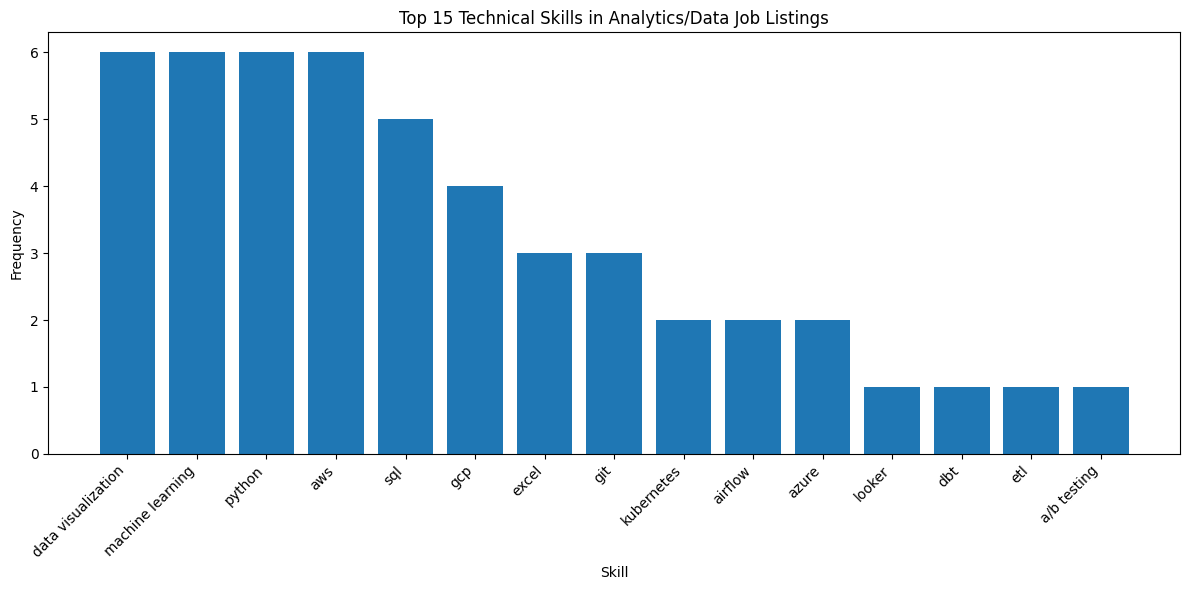

In [16]:
# 16) TOP SKILLS

top_skills = skills_exploded["skill"].value_counts().reset_index()
top_skills.columns = ["skill", "count"]

top_skills_path = os.path.join(OUTPUT_DIR, "top_skills.csv")
top_skills.to_csv(top_skills_path, index=False)

print("\nTop skills:")
display(top_skills.head(15))

plt.figure(figsize=(12, 6))
plt.bar(top_skills["skill"].head(15), top_skills["count"].head(15))
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 Technical Skills in Analytics/Data Job Listings")
plt.xlabel("Skill")
plt.ylabel("Frequency")
save_plot("top_15_skills.png")
plt.show()


Role family distribution:


,role_family,count
0,Other,10
1,Data Analyst,9
2,ML Engineer,3
3,Data Engineer,3
4,Data Scientist,1


Saved plot: /content/job_market_project_outputs/role_family_distribution.png


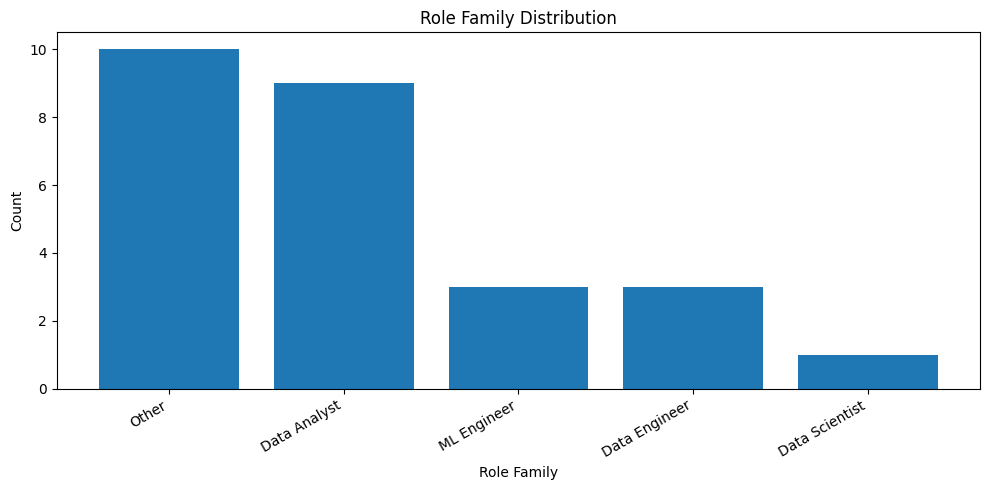

In [17]:
# 17) ROLE FAMILY DISTRIBUTION

role_counts = analytics_df["role_family"].value_counts().reset_index()
role_counts.columns = ["role_family", "count"]

print("\nRole family distribution:")
display(role_counts)

plt.figure(figsize=(10, 5))
plt.bar(role_counts["role_family"], role_counts["count"])
plt.xticks(rotation=30, ha="right")
plt.title("Role Family Distribution")
plt.xlabel("Role Family")
plt.ylabel("Count")
save_plot("role_family_distribution.png")
plt.show()


Seniority distribution:


,seniority,count
0,Unspecified,13
1,Senior,10
2,Manager+,3


Saved plot: /content/job_market_project_outputs/seniority_distribution.png


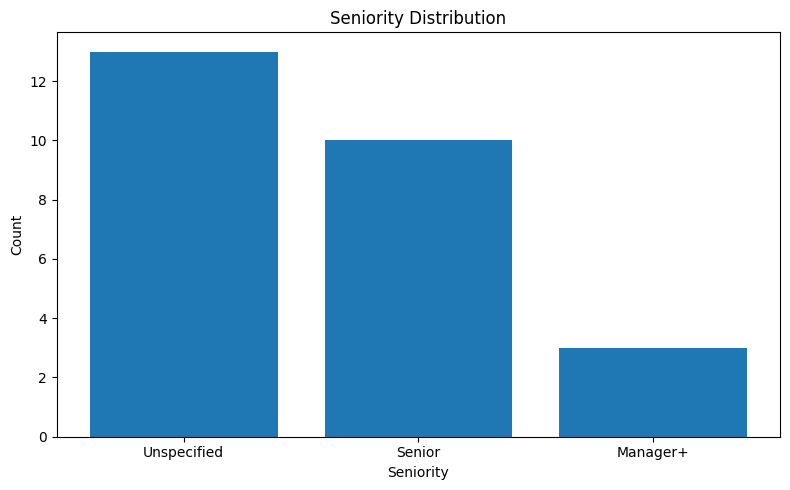

In [18]:
# 18) SENIORITY DISTRIBUTION

seniority_counts = analytics_df["seniority"].value_counts().reset_index()
seniority_counts.columns = ["seniority", "count"]

print("\nSeniority distribution:")
display(seniority_counts)

plt.figure(figsize=(8, 5))
plt.bar(seniority_counts["seniority"], seniority_counts["count"])
plt.title("Seniority Distribution")
plt.xlabel("Seniority")
plt.ylabel("Count")
save_plot("seniority_distribution.png")
plt.show()

In [19]:
# 19) TOP SKILLS BY ROLE FAMILY

top_skills_by_role = (
    skills_exploded.groupby(["role_family", "skill"])
    .size()
    .reset_index(name="count")
    .sort_values(["role_family", "count"], ascending=[True, False])
)

top_skills_by_role_path = os.path.join(OUTPUT_DIR, "top_skills_by_role_family.csv")
top_skills_by_role.to_csv(top_skills_by_role_path, index=False)

print("\nTop skills by role family:")
for family in top_skills_by_role["role_family"].dropna().unique():
    print(f"\n{family}")
    display(top_skills_by_role[top_skills_by_role["role_family"] == family].head(10))


Top skills by role family:

Data Analyst


,role_family,skill,count
4,Data Analyst,data visualization,4
0,Data Analyst,airflow,2
1,Data Analyst,aws,2
6,Data Analyst,excel,2
10,Data Analyst,machine learning,2
12,Data Analyst,python,2
2,Data Analyst,azure,1
3,Data Analyst,bigquery,1
5,Data Analyst,dbt,1
7,Data Analyst,gcp,1



Data Engineer


,role_family,skill,count
19,Data Engineer,sql,2
13,Data Engineer,aws,1
14,Data Engineer,azure,1
15,Data Engineer,etl,1
16,Data Engineer,gcp,1
17,Data Engineer,git,1
18,Data Engineer,python,1



Data Scientist


,role_family,skill,count
20,Data Scientist,r,1



ML Engineer


,role_family,skill,count
22,ML Engineer,machine learning,2
21,ML Engineer,kubernetes,1
23,ML Engineer,python,1
24,ML Engineer,sql,1



Other


,role_family,skill,count
26,Other,aws,3
27,Other,data visualization,2
29,Other,gcp,2
32,Other,machine learning,2
33,Other,python,2
34,Other,sql,2
25,Other,a/b testing,1
28,Other,excel,1
30,Other,git,1
31,Other,kubernetes,1


In [20]:
# 20) SALARY ANALYSIS

print("\nNote: salary analysis is approximate because job boards may mix pay frequencies/currencies across listings.")

skills_exploded_salary = skills_exploded.dropna(subset=["salary_avg"]).copy()
skills_exploded_salary = skills_exploded_salary[skills_exploded_salary["salary_avg"] > 0]

if len(skills_exploded_salary) >= 10:
    salary_by_skill = (
        skills_exploded_salary.groupby("skill")
        .agg(job_count=("id", "count"), avg_salary=("salary_avg", "mean"))
        .reset_index()
    )

    salary_by_skill = salary_by_skill[salary_by_skill["job_count"] >= 3].sort_values("avg_salary", ascending=False)
    salary_by_skill_path = os.path.join(OUTPUT_DIR, "salary_by_skill.csv")
    salary_by_skill.to_csv(salary_by_skill_path, index=False)

    print("\nAverage salary by skill:")
    display(salary_by_skill.head(15))

    if not salary_by_skill.empty:
        plt.figure(figsize=(12, 6))
        top_salary_skills = salary_by_skill.head(15)
        plt.bar(top_salary_skills["skill"], top_salary_skills["avg_salary"])
        plt.xticks(rotation=45, ha="right")
        plt.title("Average Salary by Skill (Approximate)")
        plt.xlabel("Skill")
        plt.ylabel("Average Salary")
        save_plot("average_salary_by_skill.png")
        plt.show()
else:
    print("Skipping salary analysis: not enough valid non-zero salary rows.")
    salary_by_skill = pd.DataFrame(columns=["skill", "job_count", "avg_salary"])


Note: salary analysis is approximate because job boards may mix pay frequencies/currencies across listings.
Skipping salary analysis: not enough valid non-zero salary rows.


In [21]:
# 21) TF-IDF ANALYSIS

TFIDF_EXTRA_STOPWORDS = {
    "jobs", "job", "remote", "islands", "island", "work", "working", "experience",
    "company", "team", "role", "position", "new", "join", "apply",
    "using", "years", "year", "business", "data", "product", "marketing",
    "design", "saint", "ll", "people", "brands", "you", "youâ",
    "content", "south", "san", "francisco", "area", "follow"
}
custom_tfidf_stopwords = list(set(ENGLISH_STOP_WORDS).union(TFIDF_EXTRA_STOPWORDS))

nlp_df = analytics_df.copy()
nlp_df["nlp_text"] = nlp_df["combined_text"].fillna("").astype(str)
nlp_df = nlp_df[nlp_df["nlp_text"].str.len() > 100].copy()

if len(nlp_df) >= 3:
    try:
        vectorizer = TfidfVectorizer(
            stop_words=custom_tfidf_stopwords,
            max_features=3000,
            ngram_range=(1, 2),
            min_df=2
        )
        X = vectorizer.fit_transform(nlp_df["nlp_text"])
        feature_names = np.array(vectorizer.get_feature_names_out())

        def top_tfidf_terms_by_group(df_input, sparse_matrix, group_col, top_n=12):
            results = {}
            for group_name in sorted(df_input[group_col].dropna().unique()):
                idx = df_input[df_input[group_col] == group_name].index
                row_positions = [df_input.index.get_loc(i) for i in idx]
                if len(row_positions) < 2:
                    continue
                mean_scores = np.asarray(sparse_matrix[row_positions].mean(axis=0)).ravel()
                top_idx = mean_scores.argsort()[::-1][:top_n]
                results[group_name] = pd.DataFrame({
                    "term": feature_names[top_idx],
                    "mean_tfidf": mean_scores[top_idx]
                })
            return results

        tfidf_results = top_tfidf_terms_by_group(nlp_df, X, "role_family", top_n=12)

        print("\nTop TF-IDF terms by role family:")
        combined_tfidf = []

        for group_name, result_df in tfidf_results.items():
            print(f"\n{group_name}")
            display(result_df)
            temp = result_df.copy()
            temp["role_family"] = group_name
            combined_tfidf.append(temp)

        if combined_tfidf:
            combined_tfidf_df = pd.concat(combined_tfidf, ignore_index=True)
            combined_tfidf_path = os.path.join(OUTPUT_DIR, "tfidf_terms_by_role_family.csv")
            combined_tfidf_df.to_csv(combined_tfidf_path, index=False)
            print(f"Saved: {combined_tfidf_path}")

    except ValueError as e:
        print("TF-IDF skipped:", e)
else:
    print("TF-IDF skipped: not enough text rows.")


Top TF-IDF terms by role family:

Data Analyst


,term,mean_tfidf
0,security,0.127903
1,financial,0.079978
2,automation,0.064989
3,management,0.063130
4,operations,0.058991
5,cloud,0.056998
6,engineering,0.051600
7,support,0.044647
8,operational,0.043893
9,healthcare,0.043493



Data Engineer


,term,mean_tfidf
0,gtm,0.207788
1,backend,0.131558
2,ehr,0.127993
3,systems,0.110349
4,care,0.106443
5,healthcare,0.102494
6,clinical,0.087357
7,health,0.085943
8,engineering,0.081859
9,engineer,0.078253



ML Engineer


,term,mean_tfidf
0,ai,0.167318
1,reliability,0.106932
2,systems,0.086950
3,care,0.072685
4,personalization,0.070426
5,machine,0.070129
6,machine learning,0.070129
7,learning engineer,0.069203
8,experiences,0.068863
9,help,0.067056



Other


,term,mean_tfidf
0,security,0.130916
1,financial,0.073598
2,ai,0.061755
3,developer,0.057420
4,cloud,0.055446
5,backend,0.050502
6,storage,0.049299
7,software,0.048893
8,engineering,0.048594
9,insurance,0.044711


Saved: /content/job_market_project_outputs/tfidf_terms_by_role_family.csv


Saved plot: /content/job_market_project_outputs/clean_wordcloud.png


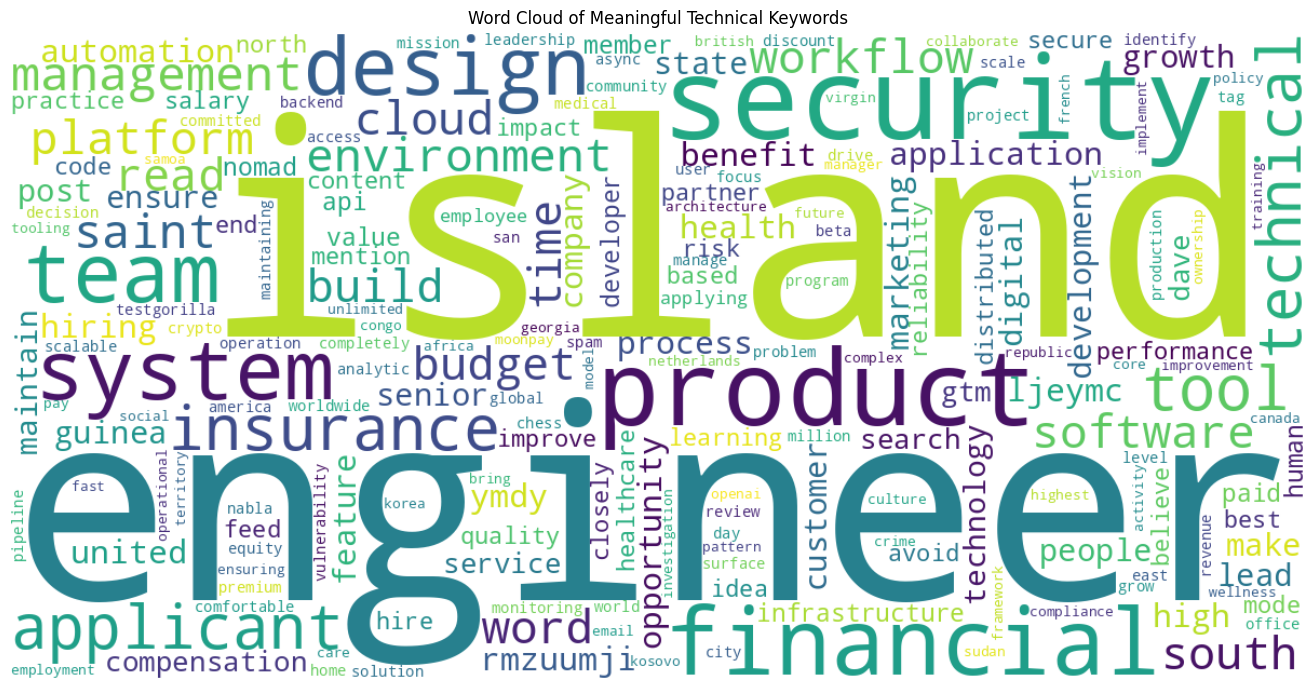

In [22]:
# 22) WORD CLOUD

custom_stopwords = set([
    "experience", "work", "team", "business", "data", "job",
    "role", "skills", "using", "ability", "including", "remote",
    "requirements", "responsibilities", "looking", "candidate",
    "must", "will", "company", "position", "apply", "posted",
    "year", "years", "join", "building", "strong", "support",
    "working", "provide", "help", "need", "jobs", "new"
])

all_stopwords = set(STOPWORDS).union(ENGLISH_STOP_WORDS).union(custom_stopwords)

clean_text_wc = " ".join(
    analytics_df["combined_text"]
    .dropna()
    .apply(lambda x: clean_for_wordcloud(x, all_stopwords))
    .tolist()
)

if clean_text_wc.strip():
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=200,
        collocations=False
    ).generate(clean_text_wc)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Meaningful Technical Keywords")
    save_plot("clean_wordcloud.png")
    plt.show()
else:
    print("Word cloud skipped: not enough clean text.")


Skill co-occurrence matrix:


,data visualization,machine learning,python,aws,sql,gcp,excel,git,kubernetes,airflow
data visualization,0,0,3,3,0,1,2,2,0,0
machine learning,0,0,1,0,1,0,1,0,0,1
python,3,1,0,5,2,3,1,3,1,0
aws,3,0,5,0,2,3,1,3,1,0
sql,0,1,2,2,0,1,0,1,0,0
gcp,1,0,3,3,1,0,1,2,1,1
excel,2,1,1,1,0,1,0,1,0,0
git,2,0,3,3,1,2,1,0,0,0
kubernetes,0,0,1,1,0,1,0,0,0,0
airflow,0,1,0,0,0,1,0,0,0,0


Saved plot: /content/job_market_project_outputs/skill_cooccurrence_heatmap.png


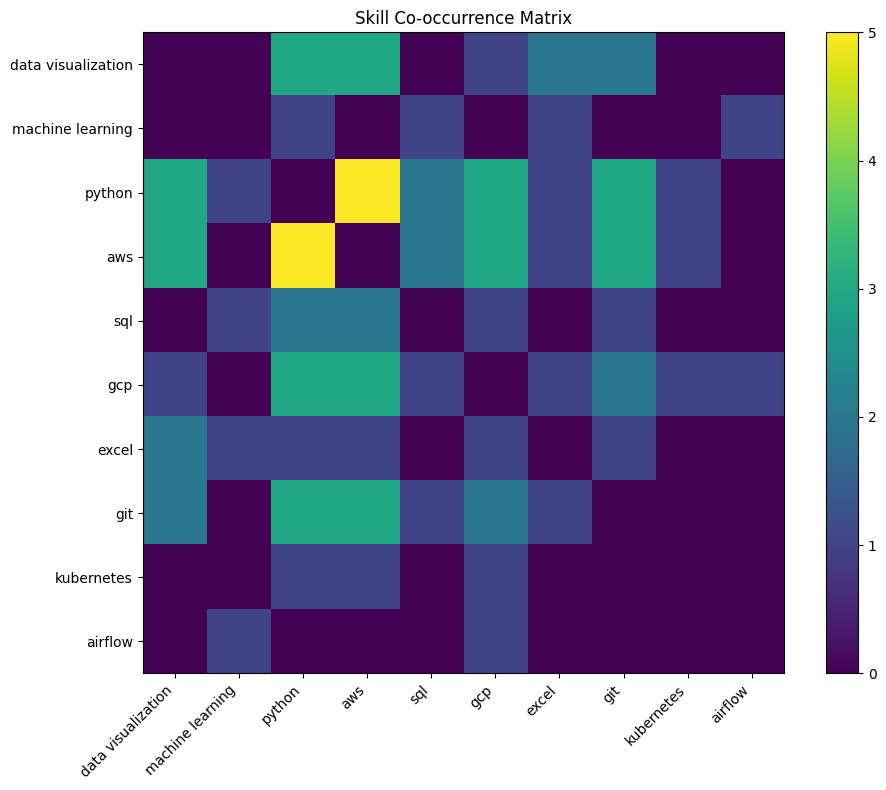

In [23]:
# 23) SKILL CO-OCCURRENCE

top_10_skill_names = top_skills["skill"].head(10).tolist()

if len(top_10_skill_names) > 1:
    cooccurrence = pd.DataFrame(0, index=top_10_skill_names, columns=top_10_skill_names)

    for skills in analytics_df["skills"]:
        skill_set = set(skills)
        filtered = [s for s in top_10_skill_names if s in skill_set]
        for s1 in filtered:
            for s2 in filtered:
                if s1 != s2:
                    cooccurrence.loc[s1, s2] += 1

    cooccurrence_path = os.path.join(OUTPUT_DIR, "skill_cooccurrence_matrix.csv")
    cooccurrence.to_csv(cooccurrence_path)

    print("\nSkill co-occurrence matrix:")
    display(cooccurrence)

    plt.figure(figsize=(10, 8))
    plt.imshow(cooccurrence.values)
    plt.xticks(range(len(top_10_skill_names)), top_10_skill_names, rotation=45, ha="right")
    plt.yticks(range(len(top_10_skill_names)), top_10_skill_names)
    plt.title("Skill Co-occurrence Matrix")
    plt.colorbar()
    save_plot("skill_cooccurrence_heatmap.png")
    plt.show()

In [24]:
# 24) SCRAPING SUMMARY

scrape_summary = pd.DataFrame({
    "metric": [
        "total_rows_analyzed",
        "pages_with_usable_text",
        "pages_with_usable_text_percent"
    ],
    "value": [
        len(analytics_df),
        int(analytics_df["page_scraped_success"].sum()),
        round(float(analytics_df["page_scraped_success"].mean() * 100), 2) if len(analytics_df) > 0 else 0.0
    ]
})

scrape_summary_path = os.path.join(OUTPUT_DIR, "scraping_summary.csv")
scrape_summary.to_csv(scrape_summary_path, index=False)

print("\nScraping summary:")
display(scrape_summary)


Scraping summary:


,metric,value
0,total_rows_analyzed,26.00
1,pages_with_usable_text,11.00
2,pages_with_usable_text_percent,42.31


In [25]:
# 25) DASHBOARD EXPORT

dashboard_df = analytics_df[[
    "id", "date", "company", "position", "location",
    "role_family", "seniority", "salary_min", "salary_max",
    "salary_avg", "url", "job_url", "page_scraped_success"
]].copy()

dashboard_df["skills"] = analytics_df["skills"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else ""
)

dashboard_path = os.path.join(OUTPUT_DIR, "dashboard_jobs_summary.csv")
dashboard_df.to_csv(dashboard_path, index=False)

print(f"Saved: {dashboard_path}")

Saved: /content/job_market_project_outputs/dashboard_jobs_summary.csv


In [26]:
# 26) FINAL SUMMARY

print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"Total analytics/data jobs analyzed: {len(analytics_df)}")
print(f"Pages with usable text: {int(analytics_df['page_scraped_success'].sum())}")

print("\nTop role families:")
print(analytics_df["role_family"].value_counts().head(10))

print("\nTop skills:")
print(top_skills.head(10))

print("\nSeniority distribution:")
print(analytics_df["seniority"].value_counts())

if not salary_by_skill.empty:
    print("\nHighest-paying skills (approximate):")
    print(salary_by_skill.head(10))

print("\nSuggested portfolio bullets:")
portfolio_bullets = [
    "Built a hybrid web-data pipeline using API extraction and HTML scraping of individual job pages.",
    "Cleaned and merged structured job metadata with scraped page text for richer NLP analysis.",
    "Extracted technical skills from unstructured job descriptions using regex-based text processing.",
    "Analyzed role families, seniority distribution, skill frequency, salary trends, and skill co-occurrence.",
    "Exported dashboard-ready CSV files and visual assets for Power BI or Tableau."
]
for i, bullet in enumerate(portfolio_bullets, 1):
    print(f"{i}. {bullet}")

print("\nAll outputs saved in:")
print(OUTPUT_DIR)
print("\nDone.")


PROJECT SUMMARY
Total analytics/data jobs analyzed: 26
Pages with usable text: 11

Top role families:
role_family
Other             10
Data Analyst       9
ML Engineer        3
Data Engineer      3
Data Scientist     1
Name: count, dtype: int64

Top skills:
                skill  count
0  data visualization      6
1    machine learning      6
2              python      6
3                 aws      6
4                 sql      5
5                 gcp      4
6               excel      3
7                 git      3
8          kubernetes      2
9             airflow      2

Seniority distribution:
seniority
Unspecified    13
Senior         10
Manager+        3
Name: count, dtype: int64

Suggested portfolio bullets:
1. Built a hybrid web-data pipeline using API extraction and HTML scraping of individual job pages.
2. Cleaned and merged structured job metadata with scraped page text for richer NLP analysis.
3. Extracted technical skills from unstructured job descriptions using regex-based 